['features.0', 'features.1', 'features.3', 'features.4', 'features.7', 'features.8', 'features.10', 'features.11', 'features.14', 'features.15', 'features.17', 'features.18', 'features.20', 'features.21', 'features.24', 'features.25', 'features.27', 'features.28', 'features.30', 'features.31', 'conv5_1', 'bn5_1', 'conv5_2', 'bn5_2', 'conv5_3', 'bn5_3', 'fc1', 'fc2', 'fc3']
Selected layers (last 3):
   fc1
   fc2
   fc3


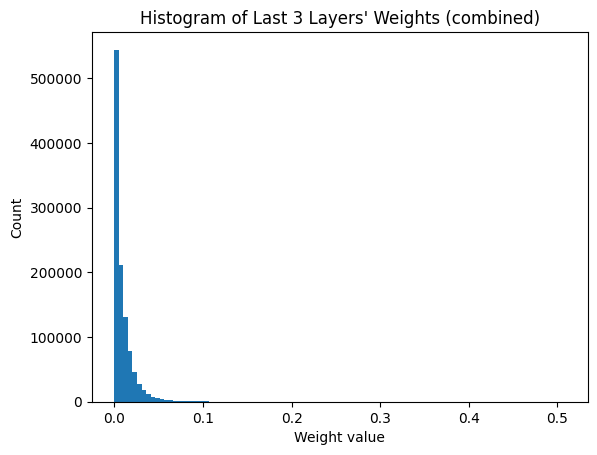

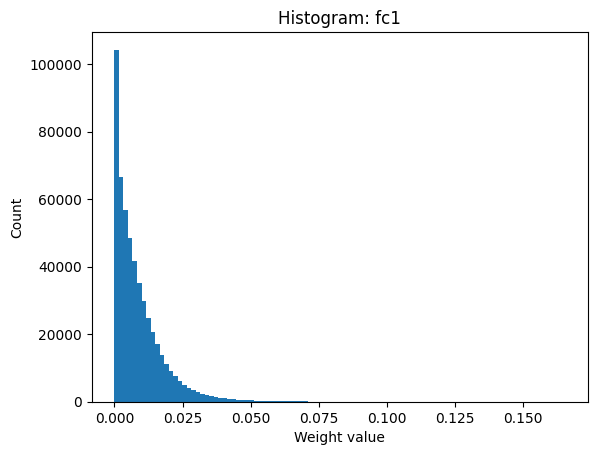

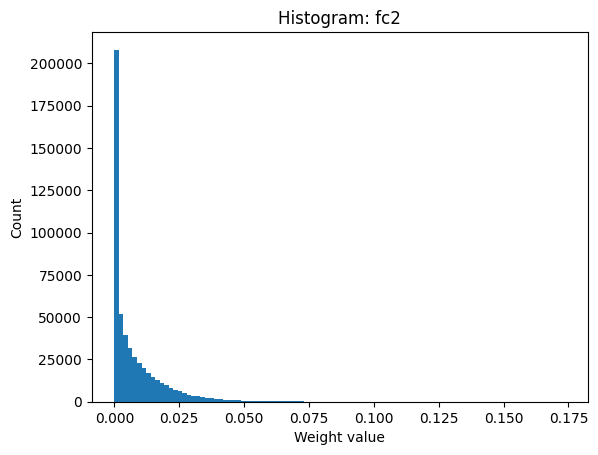

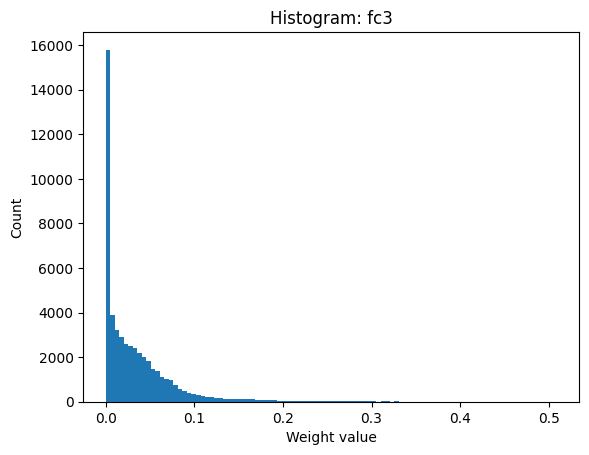

In [5]:
# pip install torch matplotlib  # if needed

import torch
import matplotlib.pyplot as plt
import numpy as np

ckpt_path = "CNN/models/new/vgg16_100_ori_relu.pth"   # <-- change this

# --- 1) Load checkpoint on CPU ---
obj = torch.load(ckpt_path, map_location="cpu")

if isinstance(obj, dict) and any(isinstance(v, torch.Tensor) for v in obj.values()):
    state_dict = obj
elif isinstance(obj, dict) and "state_dict" in obj and isinstance(obj["state_dict"], dict):
    state_dict = obj["state_dict"]
elif hasattr(obj, "state_dict"):
    state_dict = obj.state_dict()
else:
    raise ValueError("Couldn't find a state_dict in this checkpoint.")

# --- 2) Keep only floating-point ".weight" tensors (no biases/BN stats) ---
param_items = []
for name, tensor in state_dict.items():
    if (
        isinstance(tensor, torch.Tensor)
        and tensor.dtype.is_floating_point
        and name.endswith(".weight")
    ):
        param_items.append((name, tensor))

if len(param_items) == 0:
    raise ValueError("No floating-point .weight tensors found.")

# --- 3) Derive layer names and pick the LAST THREE layers ---
# Define a "layer" as everything before the final ".weight" (e.g., "encoder.layers.23.mlp.fc2")
ordered_layers = []
seen = set()
for name, _ in param_items:
    layer = name.rsplit(".", 1)[0]
    if layer not in seen:
        ordered_layers.append(layer)
        seen.add(layer)
        
print(ordered_layers)

last_three_layers = ordered_layers[-3:]
print("Selected layers (last 3):")
for L in last_three_layers:
    print("  ", L)

# --- 4) Collect weights for those three layers ---
selected = []
for name, tensor in param_items:
    layer = name.rsplit(".", 1)[0]
    if layer in last_three_layers:
        selected.append((layer, tensor.detach().cpu().reshape(-1)))

if not selected:
    raise ValueError("No matching .weight tensors for the last three layers.")

# --- 5) Plot a combined histogram of the last-3 layers' weights ---
combined = torch.cat([t for _, t in selected]).numpy()
plt.figure()
plt.hist(np.abs(combined), bins=100)
plt.title("Histogram of Last 3 Layers' Weights (combined)")
plt.xlabel("Weight value")
plt.ylabel("Count")
plt.yscale("linear")   # use "log" if very peaky
plt.show()

# --- 6) (Optional) Per-layer histograms ---
for layer in last_three_layers:
    layer_weights = torch.cat([t for L, t in selected if L == layer]).numpy()
    plt.figure()
    plt.hist(np.abs(layer_weights), bins=100)
    plt.title(f"Histogram: {layer}")
    plt.xlabel("Weight value")
    plt.ylabel("Count")
    plt.yscale("linear")  # or "log"
    plt.show()
